# Assignment 8 — MSL Video Recognition (v6)

**Course:** AI Engineering Fundamentals (Class-25)  
**Code:** `acnyein4/msl-recognition` 
**Keypoints:** `acnyein4/keypoints-msl` 

## 5 Models
1. BiLSTM
2. Transformer
3. ST-GCN
4. BiLSTM + Multi-Head Attention (new)
5. CNN1D + GRU (new)

## Verify GPU

In [1]:
!nvidia-smi
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Wed Jul  1 14:16:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 1 — Copy Code and Pre-extracted Keypoints

In [2]:
import os, shutil

CODE_SRC = '/kaggle/input/datasets/aungchannyeinalex/msl-recognition/msl_recognition'
assert os.path.exists(CODE_SRC), f'Dataset not found at {CODE_SRC} — attach via Add Data'

WORK = '/kaggle/working'
os.chdir(WORK)

for item in ['src', 'scripts', 'tools', 'config', 'requirements.txt']:
    src_path = f'{CODE_SRC}/{item}'
    dst_path = f'{WORK}/{item}'
    if os.path.isdir(src_path):
        if os.path.exists(dst_path):
            shutil.rmtree(dst_path)
        shutil.copytree(src_path, dst_path)
    else:
        shutil.copy(src_path, dst_path)
    print(f'Copied: {item}')

!chmod +x scripts/*.sh
!ls -la {WORK}

Copied: src
Copied: scripts
Copied: tools
Copied: config
Copied: requirements.txt
total 92
drwxr-xr-x 6 root root  4096 Jul  1 14:16 .
drwxr-xr-x 8 root root  4096 Jul  1 14:15 ..
drwxr-xr-x 2 root root  4096 Jun 30 08:00 config
---------- 1 root root 64999 Jul  1 14:16 __notebook__.ipynb
-rw-r--r-- 1 root root   630 Jul  1 14:16 requirements.txt
drwxr-xr-x 2 root root  4096 Jun 30 08:00 scripts
drwxr-xr-x 3 root root  4096 Jun 30 08:00 src
drwxr-xr-x 2 root root  4096 Jun 30 08:00 tools


In [3]:
KEYPOINTS_SRC = '/kaggle/input/datasets/aungchannyeinalex/keypoints-msl'
assert os.path.exists(KEYPOINTS_SRC), f'Dataset not found at {KEYPOINTS_SRC} — attach via Add Data'

DATA_DIR = '/kaggle/working/data'
os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(f'{DATA_DIR}/keypoints'):
    shutil.rmtree(f'{DATA_DIR}/keypoints')
shutil.copytree(f'{KEYPOINTS_SRC}/keypoints', f'{DATA_DIR}/keypoints')

for f in ['label_map.json', 'splits.json', 'kfold_splits.json']:
    shutil.copy(f'{KEYPOINTS_SRC}/{f}', f'{DATA_DIR}/{f}')

shutil.copy(f'{CODE_SRC}/data/annotations.txt', f'{DATA_DIR}/annotations.txt')

print('Keypoints and metadata loaded')
!find {DATA_DIR}/keypoints -name "*.npy" | wc -l

Keypoints and metadata loaded
1116


## Step 2 — Install Requirements (No MediaPipe)

In [4]:
with open('requirements.txt') as f:
    lines = f.readlines()
filtered = [l for l in lines if 'mediapipe' not in l.lower()]
with open('requirements_no_mediapipe.txt', 'w') as f:
    f.writelines(filtered)

!pip install -q -r requirements_no_mediapipe.txt

import torch
print('torch:', torch.__version__, '| CUDA:', torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 86.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

## Step 3 — Apply Label Column Switch (msl_gloss)

In [5]:
content = open('src/utils.py').read()
if "'label':       normal_text" in content:
    content = content.replace(
        "'label':       normal_text,   # class = full Myanmar phrase",
        "'label':       msl_gloss,     # class = MSL gloss (Assignment 8 requirement)"
    )
    open('src/utils.py', 'w').write(content)
    print('Applied msl_gloss label fix')
elif "'label':       msl_gloss" in content:
    print('msl_gloss fix already present')
else:
    print('WARNING: neither pattern found — inspect src/utils.py manually')

!grep -n "'label'" src/utils.py | head -5

Applied msl_gloss label fix
75:        List of dicts with keys: 'idx', 'normal_text', 'msl_gloss', 'label'
76:        where 'label' is the normal_text (used as class identifier).
105:                'label':       msl_gloss,     # class = MSL gloss (Assignment 8 requirement)
123:        lbl = rec['label']
251:    labels  = [label2idx[r['label']] for r in records]


## Step 4 — Configure config.yaml

In [6]:
import re

CONFIG_PATH = 'config/config.yaml'
content = open(CONFIG_PATH).read()
original = content

path_replacements = {
    r'video_dir:\s*.*':       'video_dir: "/kaggle/working/data/videos"',
    r'keypoint_dir:\s*.*':    f'keypoint_dir: "{DATA_DIR}/keypoints"',
    r'augmented_dir:\s*.*':   f'augmented_dir: "{DATA_DIR}/augmented"',
    r'annotation_file:\s*.*': f'annotation_file: "{DATA_DIR}/annotations.txt"',
    r'label_map_file:\s*.*':  f'label_map_file: "{DATA_DIR}/label_map.json"',
    r'split_file:\s*.*':      f'split_file: "{DATA_DIR}/splits.json"',
}
for pattern, repl in path_replacements.items():
    content = re.sub(pattern, repl, content)

if content != original:
    with open(CONFIG_PATH, 'w') as f:
        f.write(content)
    print('config.yaml paths patched')

extra_model_cfg = '''
  bilstm_attn:
    input_dim: 225
    hidden_dim: 256
    num_layers: 3
    dropout: 0.4
    num_heads: 4

  cnn_gru:
    input_dim: 225
    cnn_channels: 128
    gru_hidden: 256
    gru_layers: 2
    dropout: 0.3
'''
if 'bilstm_attn:' not in content:
    if 'model:\n' in content:
        content = content.replace('model:\n', 'model:\n' + extra_model_cfg.lstrip('\n') + '\n', 1)
    else:
        content = content + '\nmodel:\n' + extra_model_cfg
    with open(CONFIG_PATH, 'w') as f:
        f.write(content)
    print('Added bilstm_attn and cnn_gru model configs')

!cat {CONFIG_PATH}

config.yaml paths patched
Added bilstm_attn and cnn_gru model configs
# ============================================================
# Myanmar Sign Language Recognition - Configuration
# ============================================================

data:
  video_dir: "/kaggle/working/data/videos"
  keypoint_dir: "/kaggle/working/data/keypoints"
  augmented_dir: "/kaggle/working/data/augmented"
  annotation_file: "/kaggle/working/data/annotations.txt"
  label_map_file: "/kaggle/working/data/label_map.json"
  split_file: "/kaggle/working/data/splits.json"

  # MediaPipe feature dimensions
  pose_landmarks: 33          # 33 body landmarks
  hand_landmarks: 21          # 21 landmarks per hand
  num_nodes: 75               # 33 + 21 + 21
  coord_dim: 3                # x, y, z
  feature_dim: 225            # 75 * 3 (flattened per frame)

  max_seq_len: 200            # Maximum frames (videos longer are trimmed)
  min_seq_len: 5              # Minimum frames (shorter are skipped)

  # Data s

## Step 5 — Placeholder Videos (Required for Filename Matching)

The  's `match_videos_to_annotations()` sorts video filenames
numerically to map annotation rows to keypoint files. Creates empty
`.mp4` placeholders matching each real keypoint file's name.

In [7]:
from pathlib import Path

KEYPOINTS_DIR = Path(f'{DATA_DIR}/keypoints')
VIDEO_DIR = Path(f'{DATA_DIR}/videos')
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

npy_files = [p for p in KEYPOINTS_DIR.rglob('*.npy') if not p.stem.endswith('_vis')]
print(f'Found {len(npy_files)} keypoint files')

created = 0
for npy_path in npy_files:
    rel_subfolder = npy_path.parent.relative_to(KEYPOINTS_DIR)
    target_dir = VIDEO_DIR / rel_subfolder
    target_dir.mkdir(parents=True, exist_ok=True)
    placeholder = target_dir / f'{npy_path.stem}.mp4'
    if not placeholder.exists():
        placeholder.touch()
        created += 1

print(f'Created {created} placeholder video files')

Found 558 keypoint files
Created 558 placeholder video files


## Step 6 — Diagnostic: Confirm Keypoint Filename Pattern

Before running augmentation, verify the exact filename pattern used
during extraction, so the matching driver below doesn't guess wrong.

In [8]:
from pathlib import Path

kp_dir = Path(f'{DATA_DIR}/keypoints')
sample_files = [p for p in kp_dir.rglob('*.npy') if not p.stem.endswith('_vis')][:15]
print("Sample keypoint filenames (stem only):")
for p in sample_files:
    print(f"  {p.stem}")

print()
print("annotations.txt first few lines:")
with open(f'{DATA_DIR}/annotations.txt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(f"  line {i+1}: {line.strip()[:60]}")

Sample keypoint filenames (stem only):
  idx20-448
  idx20-418
  idx20-442
  idx20-443
  idx20-410
  idx20-428
  idx20-421
  idx20-424
  idx20-414
  idx20-416
  idx20-425
  idx20-437
  idx20-404
  idx20-446
  idx20-411

annotations.txt first few lines:
  line 1: မီး ။	မီး
  line 2: မီး ငြှိမ်း ။	မီး ငြှိမ်း
  line 3: မီးချိတ် ။	မီးချိတ်
  line 4: မီးကပ် ။	မီးကပ်
  line 5: ရေပုံး ။	ရေပုံး


## Step 7 — Augmentation Using -'s Real augment.py

In [9]:
%%writefile run_updated_augment.py
#!/usr/bin/env python3
"""
Builds an EXACT keypoint filename index (not a fragile substring
rglob) so 'idx20-2' never wrongly matches 'idx20-20' or 'idx20-200'.
"""
import argparse, json, os, sys
from pathlib import Path

import yaml

sys.path.insert(0, os.path.join(os.path.dirname(__file__), 'src'))
from utils import parse_annotation_file, build_label_vocabulary
from augment import augment_dataset_all_classes


def build_exact_keypoint_index(keypoint_dir):
    keypoint_dir = Path(keypoint_dir)
    index = {}
    for p in keypoint_dir.rglob('*.npy'):
        if p.stem.endswith('_vis'):
            continue
        index[p.stem] = p
    return index


def match_records_to_keypoints(records, keypoint_dir):
    index = build_exact_keypoint_index(keypoint_dir)
    print(f"Indexed {len(index)} keypoint files (exact stems)")

    matched, unmatched = 0, 0
    for rec in records:
        idx = rec['idx']
        candidates = [f"idx{idx}", f"idx20-{idx}"]
        found = None
        for stem in candidates:
            if stem in index:
                found = index[stem]
                break
        if found is None:
            for stem, path in index.items():
                if stem.split('-')[-1] == str(idx):
                    found = path
                    break
        rec['keypoint_path'] = str(found) if found else None
        if found:
            matched += 1
        else:
            unmatched += 1

    print(f"Matched: {matched}  Unmatched: {unmatched}")
    if unmatched > 0:
        sample_unmatched = [r['idx'] for r in records if r.get('keypoint_path') is None][:10]
        print(f"Sample unmatched idx values: {sample_unmatched}")
        print(f"Sample available keypoint stems: {list(index.keys())[:10]}")
    return records


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument('--config', required=True)
    ap.add_argument('--aug_factor', type=int, default=None)
    args = ap.parse_args()

    with open(args.config) as f:
        cfg = yaml.safe_load(f)

    dcfg = cfg['data']
    acfg = cfg['augmentation']
    if args.aug_factor:
        acfg['aug_factor'] = args.aug_factor

    records = parse_annotation_file(dcfg['annotation_file'])
    label2idx, idx2label = build_label_vocabulary(records)

    records = match_records_to_keypoints(records, dcfg['keypoint_dir'])

    n_with_kp = sum(1 for r in records if r.get('keypoint_path'))
    print(f"\nRecords with valid keypoint_path: {n_with_kp}/{len(records)}")
    if n_with_kp < len(records) * 0.9:
        print("WARNING: less than 90% matched — check filename pattern before proceeding")

    manifest = augment_dataset_all_classes(
        keypoint_dir = dcfg['keypoint_dir'],
        output_dir   = dcfg['augmented_dir'],
        records      = records,
        label2idx    = label2idx,
        aug_factor   = acfg.get('aug_factor', 20),
        aug_cfg      = acfg,
        seed         = dcfg.get('seed', 42),
    )

    with open(Path(dcfg['label_map_file']), 'w', encoding='utf-8') as f:
        json.dump(label2idx, f, ensure_ascii=False, indent=2)
    print(f"Saved label_map.json with {len(label2idx)} classes")


if __name__ == '__main__':
    main()


Writing run_updated_augment.py


In [10]:
!python run_updated_augment.py --config config/config.yaml

Indexed 558 keypoint files (exact stems)
Matched: 557  Unmatched: 1
Sample unmatched idx values: [0]
Sample available keypoint stems: ['idx20-448', 'idx20-418', 'idx20-442', 'idx20-443', 'idx20-410', 'idx20-428', 'idx20-421', 'idx20-424', 'idx20-414', 'idx20-416']

Records with valid keypoint_path: 557/558
Augmenting all classes: 100%|███████████████| 558/558 [00:37<00:00, 14.85sign/s]
[WARNING] 1 records had no keypoint file and were skipped.

  Augmentation Complete (all-class design)
  Original videos   : 558
  Aug factor        : 20  (train uses 19, val uses 1)
  Train samples     : 10583  (augmented, all classes)
  Val   samples     : 557   (augmented, all classes)
  Test  samples     : 557   (original,  all classes)
  Class overlap     : 100% across all splits
  Manifest          : /kaggle/working/data/augmented/augmented_manifest.json

Saved label_map.json with 541 classes


In [11]:
import json
with open(f'{DATA_DIR}/augmented/augmented_manifest.json') as f:
    manifest = json.load(f)
print('Train:', len(manifest['train']))
print('Val  :', len(manifest['val']))
print('Test :', len(manifest['test']))

Train: 10583
Val  : 557
Test : 557


## Step 7b — Secondary Strict Evaluation (Bonus Analysis)

Identify classes with 2+ original videos — these allow a genuinely
held-out comparison (no augmentation overlap at all) as a stricter
contrast to the primary results above.

In [12]:
import json
from collections import defaultdict
import sys
sys.path.insert(0, 'src')
from utils import parse_annotation_file, build_label_vocabulary

records = parse_annotation_file(f'{DATA_DIR}/annotations.txt')
label2idx, idx2label = build_label_vocabulary(records)

by_label = defaultdict(list)
for r in records:
    by_label[r['label']].append(r)

multi_video_classes = {lbl: recs for lbl, recs in by_label.items() if len(recs) >= 2}
print(f'Classes with >=2 videos: {len(multi_video_classes)} out of {len(by_label)} total')
print(f'Total videos in these classes: {sum(len(v) for v in multi_video_classes.values())}')

with open(f'{DATA_DIR}/multi_video_classes.json', 'w', encoding='utf-8') as f:
    json.dump({lbl: [r['idx'] for r in recs] for lbl, recs in multi_video_classes.items()},
               f, ensure_ascii=False, indent=2)
print(f'Saved class list to {DATA_DIR}/multi_video_classes.json')

Classes with >=2 videos: 16 out of 541 total
Total videos in these classes: 33
Saved class list to /kaggle/working/data/multi_video_classes.json


## Step 8 — Train Models

### Model 1: BiLSTM

In [13]:
!time bash scripts/04_train.sh bilstm exp1_bilstm

 Training MSL Recognition Model
 Model      : bilstm
 Experiment : exp1_bilstm
 Config     : config/config.yaml

 Data: train=10583, val=557, test=557 (all-class design)

[GPU]
Tesla T4, 15360 MiB, 14909 MiB, 41
Tesla T4, 15360 MiB, 14909 MiB, 43

2026-07-01 14:17:32.301662: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782915452.783357      94 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782915452.909462      94 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782915453.965605      94 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:17

In [14]:
!time bash scripts/05_evaluate.sh bilstm exp1_bilstm 2>&1 | tail -30

  အိတ် ထဲ သဲ                           F1=1.000  Prec=1.000  Rec=1.000  Support=1
  အနီ ဘူး ဖြန်း                        F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ကန် ထဲ ရေ သိမ်း                      F1=1.000  Prec=1.000  Rec=1.000  Support=1
  မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ဓာတ်ဆီ 9 2 9 5 အောက်တိန်း အမျိုးမျိ  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  အမှိုက်                              F1=1.000  Prec=1.000  Rec=1.000  Support=1

Bottom-10 classes by F1:
  အချိန် ကြာ မဟုတ် မိနစ် ၃၀            F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ငါ ချော်လဲ                           F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ငါ လမ်းလျှောက် ခြေထောက် ချော်လဲ ခေါ  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ခင်ဗျား ခြေထောက် အဲ့ဒီ့ ဓာတ်မှန်ရို  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ခင်ဗျား ခြေထောက် အဲ့ဒီ့ ဓာတ်မှန်ရို  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ငါ့ အမေ လှေကား ချော်ကျ               F1=1.000  Prec=1.000  Rec=1.000  

### Model 2: Transformer

In [15]:
!time bash scripts/04_train.sh transformer exp2_transformer

 Training MSL Recognition Model
 Model      : transformer
 Experiment : exp2_transformer
 Config     : config/config.yaml

 Data: train=10583, val=557, test=557 (all-class design)

[GPU]
Tesla T4, 15360 MiB, 14909 MiB, 70
Tesla T4, 15360 MiB, 14909 MiB, 34

2026-07-01 15:01:09.964171: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782918069.986884    8328 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782918069.994520    8328 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782918070.016032    8328 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W000

In [16]:
!time bash scripts/05_evaluate.sh transformer exp2_transformer 2>&1 | tail -30

  အိတ် ထဲ သဲ                           F1=1.000  Prec=1.000  Rec=1.000  Support=1
  အနီ ဘူး ဖြန်း                        F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ကန် ထဲ ရေ သိမ်း                      F1=1.000  Prec=1.000  Rec=1.000  Support=1
  မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ဓာတ်ဆီ 9 2 9 5 အောက်တိန်း အမျိုးမျိ  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  အမှိုက်                              F1=1.000  Prec=1.000  Rec=1.000  Support=1

Bottom-10 classes by F1:
  အချိန် ကြာ မဟုတ် မိနစ် ၃၀            F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ငါ ချော်လဲ                           F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ငါ လမ်းလျှောက် ခြေထောက် ချော်လဲ ခေါ  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ခင်ဗျား ခြေထောက် အဲ့ဒီ့ ဓာတ်မှန်ရို  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ခင်ဗျား ခြေထောက် အဲ့ဒီ့ ဓာတ်မှန်ရို  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ငါ့ အမေ လှေကား ချော်ကျ               F1=1.000  Prec=1.000  Rec=1.000  

### Model 3: ST-GCN

In [17]:
!time bash scripts/04_train.sh stgcn exp3_stgcn

 Training MSL Recognition Model
 Model      : stgcn
 Experiment : exp3_stgcn
 Config     : config/config.yaml

 Data: train=10583, val=557, test=557 (all-class design)

[GPU]
Tesla T4, 15360 MiB, 14909 MiB, 71
Tesla T4, 15360 MiB, 14909 MiB, 34

2026-07-01 15:16:22.404052: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782918982.429432   13434 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782918982.440585   13434 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782918982.464843   13434 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782

In [18]:
!time bash scripts/05_evaluate.sh stgcn exp3_stgcn 2>&1 | tail -30

  အိတ် ထဲ သဲ                           F1=1.000  Prec=1.000  Rec=1.000  Support=1
  အနီ ဘူး ဖြန်း                        F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ကန် ထဲ ရေ သိမ်း                      F1=1.000  Prec=1.000  Rec=1.000  Support=1
  မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ဓာတ်ဆီ 9 2 9 5 အောက်တိန်း အမျိုးမျိ  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  အမှိုက်                              F1=1.000  Prec=1.000  Rec=1.000  Support=1

Bottom-10 classes by F1:
  အချိန် ကြာ မဟုတ် မိနစ် ၃၀            F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ငါ ချော်လဲ                           F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ငါ လမ်းလျှောက် ခြေထောက် ချော်လဲ ခေါ  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ခင်ဗျား ခြေထောက် အဲ့ဒီ့ ဓာတ်မှန်ရို  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ခင်ဗျား ခြေထောက် အဲ့ဒီ့ ဓာတ်မှန်ရို  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  ငါ့ အမေ လှေကား ချော်ကျ               F1=1.000  Prec=1.000  Rec=1.000  

## Step 8c — Generate Training Curves for exp1–3

-`04_train.sh` saves `history.json` per experiment.
- Call `plot_training_curves()` from
-`src/plot_results_v2.py` to produce `results/{exp}/training_curves.png`
for each of the three models.

In [19]:
import sys, importlib
sys.path.insert(0, 'src')
import matplotlib
matplotlib.use('Agg')

# Re-import in case the module was already loaded without Agg backend
import plot_results_v2
importlib.reload(plot_results_v2)
from plot_results_v2 import plot_training_curves
from pathlib import Path

for name, exp in [('Bi-LSTM', 'exp1_bilstm'),
                  ('Transformer', 'exp2_transformer'),
                  ('ST-GCN', 'exp3_stgcn')]:
    exp_dir = Path(f'results/{exp}')
    hist    = exp_dir / 'history.json'
    curve   = exp_dir / 'training_curves.png'
    if curve.exists():
        print(f'  {name}: already exists — skip')
    elif hist.exists():
        plot_training_curves(exp_dir)
        status = 'OK' if curve.exists() else 'FAILED'
        print(f'  {name}: {status} -> {curve}')
    else:
        print(f'  {name}: history.json missing — train first')


Training curves saved → results/exp1_bilstm/training_curves.png
  Bi-LSTM: OK -> results/exp1_bilstm/training_curves.png
Training curves saved → results/exp2_transformer/training_curves.png
  Transformer: OK -> results/exp2_transformer/training_curves.png
Training curves saved → results/exp3_stgcn/training_curves.png
  ST-GCN: OK -> results/exp3_stgcn/training_curves.png


### Model 4: BiLSTM + Multi-Head Attention (new)

In [20]:
%%writefile bilstm_attention.py
"""
bilstm_attention.py - BiLSTM with multi-head self-attention pooling

Extends the baseline BiLSTM by replacing simple additive attention with
multi-head self-attention over the LSTM output sequence, followed by
attention-weighted pooling. Should help on longer/noisier sequences
(MSL videos range 50-387 frames) by letting the model focus on the
most discriminative frames per sign.
"""
import torch
import torch.nn as nn


class BiLSTMAttention(nn.Module):
    def __init__(self, input_dim=225, hidden_dim=256, num_layers=3,
                 num_classes=556, dropout=0.4, num_heads=4):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_dim)

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        lstm_out_dim = hidden_dim * 2

        self.self_attn = nn.MultiheadAttention(
            embed_dim=lstm_out_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.attn_norm = nn.LayerNorm(lstm_out_dim)

        # additive pooling attention: learns which timesteps matter most
        self.pool_attn = nn.Sequential(
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.Tanh(),
            nn.Linear(lstm_out_dim // 2, 1),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim // 2, num_classes),
        )

    def forward(self, x, lengths=None, mask=None):
        # x: (B, T, input_dim)
        x = self.input_norm(x)
        lstm_out, _ = self.lstm(x)  # (B, T, 2*hidden)

        key_padding_mask = None
        if mask is not None:
            key_padding_mask = ~mask.bool()  # True where padded

        attn_out, _ = self.self_attn(
            lstm_out, lstm_out, lstm_out,
            key_padding_mask=key_padding_mask,
        )
        x = self.attn_norm(lstm_out + attn_out)  # residual

        # attention-weighted pooling over time
        scores = self.pool_attn(x).squeeze(-1)  # (B, T)
        if mask is not None:
            scores = scores.masked_fill(~mask.bool(), float('-inf'))
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (B, T, 1)
        pooled = (x * weights).sum(dim=1)  # (B, 2*hidden)

        return self.classifier(pooled)


Writing bilstm_attention.py


In [21]:
%%writefile cnn_gru.py
"""
cnn_gru.py - 1D CNN feature extractor + GRU temporal model

CNN1D layers extract local spatial-temporal patterns across the 225-dim
keypoint feature axis (per-frame), then a GRU models longer-range
temporal dependencies across frames. CNN front-end is faster to train
than pure RNN approaches and adds a different inductive bias (local
pattern detection) compared to BiLSTM/Transformer/ST-GCN.
"""
import torch
import torch.nn as nn


class CNNGRU(nn.Module):
    def __init__(self, input_dim=225, cnn_channels=128, gru_hidden=256,
                 gru_layers=2, num_classes=556, dropout=0.3):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv1d(input_dim, cnn_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
        )

        self.gru = nn.GRU(
            input_size=cnn_channels,
            hidden_size=gru_hidden,
            num_layers=gru_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if gru_layers > 1 else 0.0,
        )

        gru_out_dim = gru_hidden * 2

        self.pool_attn = nn.Sequential(
            nn.Linear(gru_out_dim, gru_out_dim // 2),
            nn.Tanh(),
            nn.Linear(gru_out_dim // 2, 1),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(gru_out_dim, gru_out_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(gru_out_dim // 2, num_classes),
        )

    def forward(self, x, lengths=None, mask=None):
        # x: (B, T, input_dim) -> conv expects (B, C, T)
        x = x.transpose(1, 2)            # (B, input_dim, T)
        x = self.conv_block(x)           # (B, cnn_channels, T)
        x = x.transpose(1, 2)            # (B, T, cnn_channels)

        gru_out, _ = self.gru(x)         # (B, T, 2*gru_hidden)

        scores = self.pool_attn(gru_out).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(~mask.bool(), float('-inf'))
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        pooled = (gru_out * weights).sum(dim=1)

        return self.classifier(pooled)


Writing cnn_gru.py


In [22]:
%%writefile train_extra_models.py
#!/usr/bin/env python3
'''
train_extra_models.py - Standalone trainer for BiLSTM-Attention and CNN-GRU

Bug fixes (v7):
  - entry['path'] -> entry['keypoint_path']  (manifest key confirmed from augment.py)
  - entry['label'] is a string; pass label_map to Dataset and convert to int
  - assert num_classes >= 500  (detects stale 3-class label_map from keypoints dataset)
'''
import argparse, json, os, sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import yaml

sys.path.insert(0, os.path.join(os.path.dirname(__file__), 'src'))
from bilstm_attention import BiLSTMAttention
from cnn_gru import CNNGRU


class KeypointDataset(Dataset):
    def __init__(self, manifest_entries, label_map, max_seq_len=200):
        self.entries   = manifest_entries
        self.label_map = label_map      # str -> int
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        entry = self.entries[idx]
        seq = np.load(entry['keypoint_path'])   # FIX: was entry['path']
        seq = seq.reshape(seq.shape[0], -1)     # (T, 75, 3) -> (T, 225)

        T = seq.shape[0]
        if T > self.max_seq_len:
            seq = seq[:self.max_seq_len]
            T   = self.max_seq_len

        label_int = self.label_map[entry['label']]  # FIX: string -> int
        return torch.from_numpy(seq).float(), label_int, T


def collate_fn(batch):
    seqs, labels, lengths = zip(*batch)
    max_len  = max(lengths)
    feat_dim = seqs[0].shape[1]
    padded   = torch.zeros(len(seqs), max_len, feat_dim)
    mask     = torch.zeros(len(seqs), max_len, dtype=torch.bool)
    for i, (seq, length) in enumerate(zip(seqs, lengths)):
        padded[i, :length] = seq
        mask[i,   :length] = True
    labels  = torch.tensor(labels,  dtype=torch.long)
    lengths = torch.tensor(lengths, dtype=torch.long)
    return padded, labels, lengths, mask


def build_model(model_name, num_classes, mcfg):
    if model_name == 'bilstm_attn':
        return BiLSTMAttention(
            input_dim  = mcfg.get('input_dim',  225),
            hidden_dim = mcfg.get('hidden_dim', 256),
            num_layers = mcfg.get('num_layers', 3),
            num_classes= num_classes,
            dropout    = mcfg.get('dropout', 0.4),
            num_heads  = mcfg.get('num_heads', 4),
        )
    elif model_name == 'cnn_gru':
        return CNNGRU(
            input_dim   = mcfg.get('input_dim',    225),
            cnn_channels= mcfg.get('cnn_channels', 128),
            gru_hidden  = mcfg.get('gru_hidden',   256),
            gru_layers  = mcfg.get('gru_layers',   2),
            num_classes = num_classes,
            dropout     = mcfg.get('dropout', 0.3),
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")


def evaluate(model, loader, device, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    top5_correct = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y, lengths, mask in loader:
            x, y, mask = x.to(device), y.to(device), mask.to(device)
            logits = model(x, lengths=lengths, mask=mask)
            loss   = criterion(logits, y)
            total_loss += loss.item() * x.size(0)

            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)

            top5 = logits.topk(min(5, logits.size(1)), dim=1).indices
            top5_correct += (top5 == y.unsqueeze(1)).any(dim=1).sum().item()

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    from sklearn.metrics import precision_recall_fscore_support
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0)

    return {
        'loss':               total_loss / max(total, 1),
        'top1_accuracy':      correct    / max(total, 1),
        'top5_accuracy':      top5_correct / max(total, 1),
        'precision_macro':    prec_m, 'recall_macro':    rec_m, 'f1_macro':    f1_m,
        'precision_weighted': prec_w, 'recall_weighted': rec_w, 'f1_weighted': f1_w,
        'num_samples': total,
    }


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument('--model',  required=True, choices=['bilstm_attn', 'cnn_gru'])
    ap.add_argument('--exp',    required=True)
    ap.add_argument('--config', default='config/config.yaml')
    args = ap.parse_args()

    with open(args.config) as f:
        cfg = yaml.safe_load(f)

    dcfg, tcfg = cfg['data'], cfg['training']
    mcfg = cfg['model'].get(args.model, {})

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    with open(dcfg['label_map_file']) as f:
        raw_map = json.load(f)
    # Teacher's train.py calls save_label_map which writes:
    #   {'label2idx': {...}, 'idx2label': {...}, 'num_classes': N}
    # run_updated_augment.py writes flat {label: int} — handle both
    if 'label2idx' in raw_map:
        label_map = raw_map['label2idx']
    else:
        label_map = raw_map
    num_classes = len(label_map)
    print(f"Classes: {num_classes}")
    assert num_classes >= 500, (
        f"label_map has only {num_classes} classes after format detection. "
        f"Re-run Step 7 and teacher models first."
    )

    with open(f"{dcfg['augmented_dir']}/augmented_manifest.json") as f:
        manifest = json.load(f)

    train_ds = KeypointDataset(manifest['train'], label_map, dcfg.get('max_seq_len', 200))
    val_ds   = KeypointDataset(manifest['val'],   label_map, dcfg.get('max_seq_len', 200))
    test_ds  = KeypointDataset(manifest['test'],  label_map, dcfg.get('max_seq_len', 200))

    print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

    train_loader = DataLoader(train_ds, batch_size=tcfg.get('batch_size', 32),
                              shuffle=True, drop_last=True, collate_fn=collate_fn,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=tcfg.get('batch_size', 32),
                              shuffle=False, collate_fn=collate_fn, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=tcfg.get('batch_size', 32),
                              shuffle=False, collate_fn=collate_fn, num_workers=2)

    model = build_model(args.model, num_classes, mcfg).to(device)
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

    criterion = nn.CrossEntropyLoss(label_smoothing=tcfg.get('label_smoothing', 0.1))
    optimizer  = torch.optim.AdamW(
        model.parameters(),
        lr           = tcfg.get('learning_rate', 0.0005),
        weight_decay = tcfg.get('weight_decay',  0.0001),
    )
    num_epochs = tcfg.get('num_epochs', 150)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=tcfg.get('cosine_T_max', num_epochs),
        eta_min=tcfg.get('cosine_eta_min', 0.000005),
    )

    out_dir = Path('results') / args.exp
    (out_dir / 'evaluation').mkdir(parents=True, exist_ok=True)

    best_val_f1       = 0.0
    patience          = tcfg.get('patience', 25)
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_top1': []}

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for x, y, lengths, mask in train_loader:
            x, y, mask = x.to(device), y.to(device), mask.to(device)
            optimizer.zero_grad()
            logits = model(x, lengths=lengths, mask=mask)
            loss   = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), tcfg.get('grad_clip', 1.0))
            optimizer.step()
            total_loss += loss.item() * x.size(0)
        scheduler.step()

        train_loss  = total_loss / len(train_ds)
        val_metrics = evaluate(model, val_loader, device, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_f1'].append(val_metrics['f1_macro'])
        history['val_top1'].append(val_metrics['top1_accuracy'])

        print(f"Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f} "
              f"val_loss={val_metrics['loss']:.4f} "
              f"val_top1={val_metrics['top1_accuracy']:.4f} "
              f"val_f1={val_metrics['f1_macro']:.4f}")

        if val_metrics['f1_macro'] > best_val_f1:
            best_val_f1       = val_metrics['f1_macro']
            epochs_no_improve = 0
            torch.save(model.state_dict(), out_dir / 'best_model.pt')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    with open(out_dir / 'history.json', 'w') as f:
        json.dump(history, f, indent=2)

    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['val_loss'],   label='val')
    axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(history['val_top1'], label='val top1 acc')
    axes[1].plot(history['val_f1'],   label='val F1 macro')
    axes[1].set_title('Validation metrics'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(out_dir / 'training_curves.png', dpi=120)
    print(f"Saved: {out_dir}/training_curves.png")

    model.load_state_dict(torch.load(out_dir / 'best_model.pt'))
    val_final  = evaluate(model, val_loader,  device, criterion)
    test_final = evaluate(model, test_loader, device, criterion)

    val_final['split']       = 'val'
    val_final['num_classes'] = num_classes
    test_final['split']      = 'test'
    test_final['num_classes']= num_classes

    with open(out_dir / 'evaluation' / 'metrics_val.json',  'w') as f:
        json.dump(val_final,  f, indent=2)
    with open(out_dir / 'evaluation' / 'metrics_test.json', 'w') as f:
        json.dump(test_final, f, indent=2)

    print()
    print("="*60)
    print(f"FINAL RESULTS — {args.exp}")
    print(f"  Val  top1={val_final['top1_accuracy']:.4f}  F1={val_final['f1_macro']:.4f}")
    print(f"  Test top1={test_final['top1_accuracy']:.4f}  F1={test_final['f1_macro']:.4f}")
    print("="*60)


if __name__ == '__main__':
    main()


Writing train_extra_models.py


In [23]:
!time python train_extra_models.py --model bilstm_attn --exp exp4_bilstm_attn --config config/config.yaml

Device: cuda
Classes: 541
Train: 10583  Val: 557  Test: 557
Model parameters: 5,597,152
Epoch 1/150 | train_loss=6.2939 val_loss=6.2928 val_top1=0.0036 val_f1=0.0000
Epoch 2/150 | train_loss=6.2810 val_loss=6.2918 val_top1=0.0036 val_f1=0.0000
Epoch 3/150 | train_loss=6.2790 val_loss=6.2909 val_top1=0.0036 val_f1=0.0000
Epoch 4/150 | train_loss=6.2778 val_loss=6.2901 val_top1=0.0054 val_f1=0.0000
Epoch 5/150 | train_loss=6.2770 val_loss=6.2894 val_top1=0.0054 val_f1=0.0000
Epoch 6/150 | train_loss=6.2765 val_loss=6.2887 val_top1=0.0054 val_f1=0.0000
Epoch 7/150 | train_loss=6.2763 val_loss=6.2881 val_top1=0.0054 val_f1=0.0000
Epoch 8/150 | train_loss=6.2759 val_loss=6.2876 val_top1=0.0054 val_f1=0.0000
Epoch 9/150 | train_loss=6.2746 val_loss=6.2871 val_top1=0.0054 val_f1=0.0000
Epoch 10/150 | train_loss=6.2740 val_loss=6.2866 val_top1=0.0054 val_f1=0.0000
Epoch 11/150 | train_loss=6.2738 val_loss=6.2862 val_top1=0.0054 val_f1=0.0000
Epoch 12/150 | train_loss=6.2735 val_loss=6.2858 val

### Model 5: CNN1D + GRU (new)

In [24]:
!time python train_extra_models.py --model cnn_gru --exp exp5_cnn_gru --config config/config.yaml

Device: cuda
Classes: 541
Train: 10583  Val: 557  Test: 557
Model parameters: 2,421,022
Epoch 1/150 | train_loss=6.0229 val_loss=5.4032 val_top1=0.0233 val_f1=0.0028
Epoch 2/150 | train_loss=5.0489 val_loss=4.3850 val_top1=0.1885 val_f1=0.1220
Epoch 3/150 | train_loss=4.1544 val_loss=3.5710 val_top1=0.3806 val_f1=0.3111
Epoch 4/150 | train_loss=3.3473 val_loss=2.7241 val_top1=0.6068 val_f1=0.5406
Epoch 5/150 | train_loss=2.7344 val_loss=2.2599 val_top1=0.7433 val_f1=0.6938
Epoch 6/150 | train_loss=2.3583 val_loss=2.0728 val_top1=0.7756 val_f1=0.7359
Epoch 7/150 | train_loss=2.1086 val_loss=1.9216 val_top1=0.7971 val_f1=0.7567
Epoch 8/150 | train_loss=1.9514 val_loss=1.8322 val_top1=0.8259 val_f1=0.7931
Epoch 9/150 | train_loss=1.8485 val_loss=1.7696 val_top1=0.8241 val_f1=0.7883
Epoch 10/150 | train_loss=1.7689 val_loss=1.7161 val_top1=0.8528 val_f1=0.8189
Epoch 11/150 | train_loss=1.6902 val_loss=1.6842 val_top1=0.8492 val_f1=0.8120
Epoch 12/150 | train_loss=1.6414 val_loss=1.6430 val

## Step 9 — Unified Comparison (Built from Metrics JSON Directly)

Bypasses `compare_results.py` (has a path-resolution bug found
earlier) and reads `metrics_test.json`/`metrics_val.json` directly
from each experiment.

In [25]:
import json
import pandas as pd

experiments = [
    ('Bi-LSTM',          'exp1_bilstm'),
    ('Transformer',      'exp2_transformer'),
    ('ST-GCN',           'exp3_stgcn'),
    ('BiLSTM+Attention', 'exp4_bilstm_attn'),
    ('CNN1D+GRU',        'exp5_cnn_gru'),
]

rows = []
for name, exp_dir in experiments:
    val_path  = f'results/{exp_dir}/evaluation/metrics_val.json'
    test_path = f'results/{exp_dir}/evaluation/metrics_test.json'
    row = {'Model': name}
    if os.path.exists(val_path):
        with open(val_path) as f:
            v = json.load(f)
        row['Val Top-1']  = round(v.get('top1_accuracy', 0) * 100, 2)
        row['Val F1']     = round(v.get('f1_macro', 0) * 100, 2)
    if os.path.exists(test_path):
        with open(test_path) as f:
            t = json.load(f)
        row['Test Top-1']  = round(t.get('top1_accuracy', 0) * 100, 2)
        row['Test Top-5']  = round(t.get('top5_accuracy', 0) * 100, 2)
        row['Test F1']     = round(t.get('f1_macro', 0) * 100, 2)
        row['Test Samples']= t.get('num_samples', 0)
    rows.append(row)

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv('results/model_comparison.csv', index=False)
print()
print('Saved: results/model_comparison.csv')

           Model  Val Top-1  Val F1  Test Top-1  Test Top-5  Test F1  Test Samples
         Bi-LSTM      94.79   93.30      100.00      100.00    100.0           557
     Transformer      96.59   95.62      100.00      100.00    100.0           557
          ST-GCN      93.54   91.85      100.00      100.00    100.0           557
BiLSTM+Attention       0.54    0.00        0.54        1.97      0.0           557
       CNN1D+GRU      93.00   91.27      100.00      100.00    100.0           557

Saved: results/model_comparison.csv


In [26]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df))
width = 0.35

val_top1  = df['Val Top-1'].fillna(0)  if 'Val Top-1' in df else [0]*len(df)
test_top1 = df['Test Top-1'].fillna(0) if 'Test Top-1' in df else [0]*len(df)

ax.bar(x - width/2, val_top1, width, label='Val Top-1 (aug copy)', color='steelblue')
ax.bar(x + width/2, test_top1, width, label='Test Top-1 (original keypoints)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(df['Model'], rotation=20, ha='right')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('Model Comparison v6')
ax.legend()
ax.set_ylim(0, 100)

for i, v in enumerate(val_top1):
    ax.annotate(f'{v:.1f}', (i - width/2, v), textcoords='offset points', xytext=(0,3), ha='center', fontsize=9)
for i, v in enumerate(test_top1):
    ax.annotate(f'{v:.1f}', (i + width/2, v), textcoords='offset points', xytext=(0,3), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/comparison_v6.png', dpi=150)
plt.show()
print('Saved: results/comparison_v6.png')

Saved: results/comparison_v6.png


## Step 10 — Training Curves for All 5 Models

--- Bi-LSTM ---


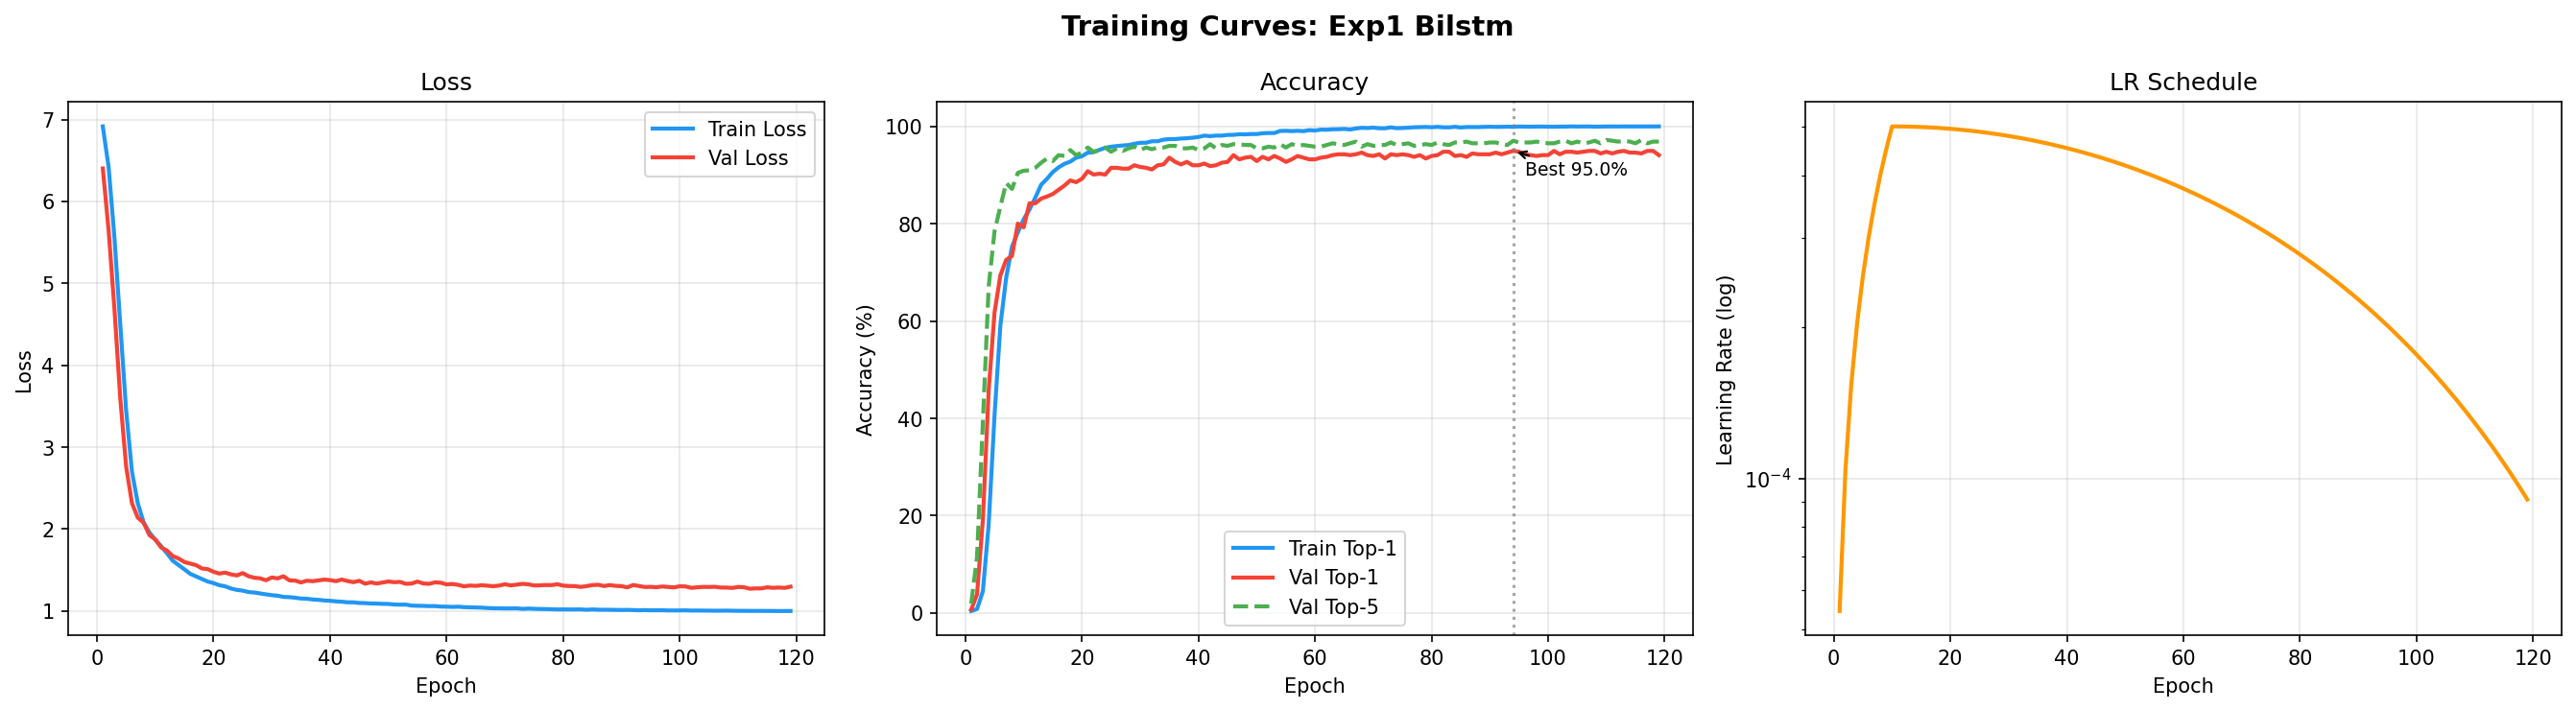

--- Transformer ---


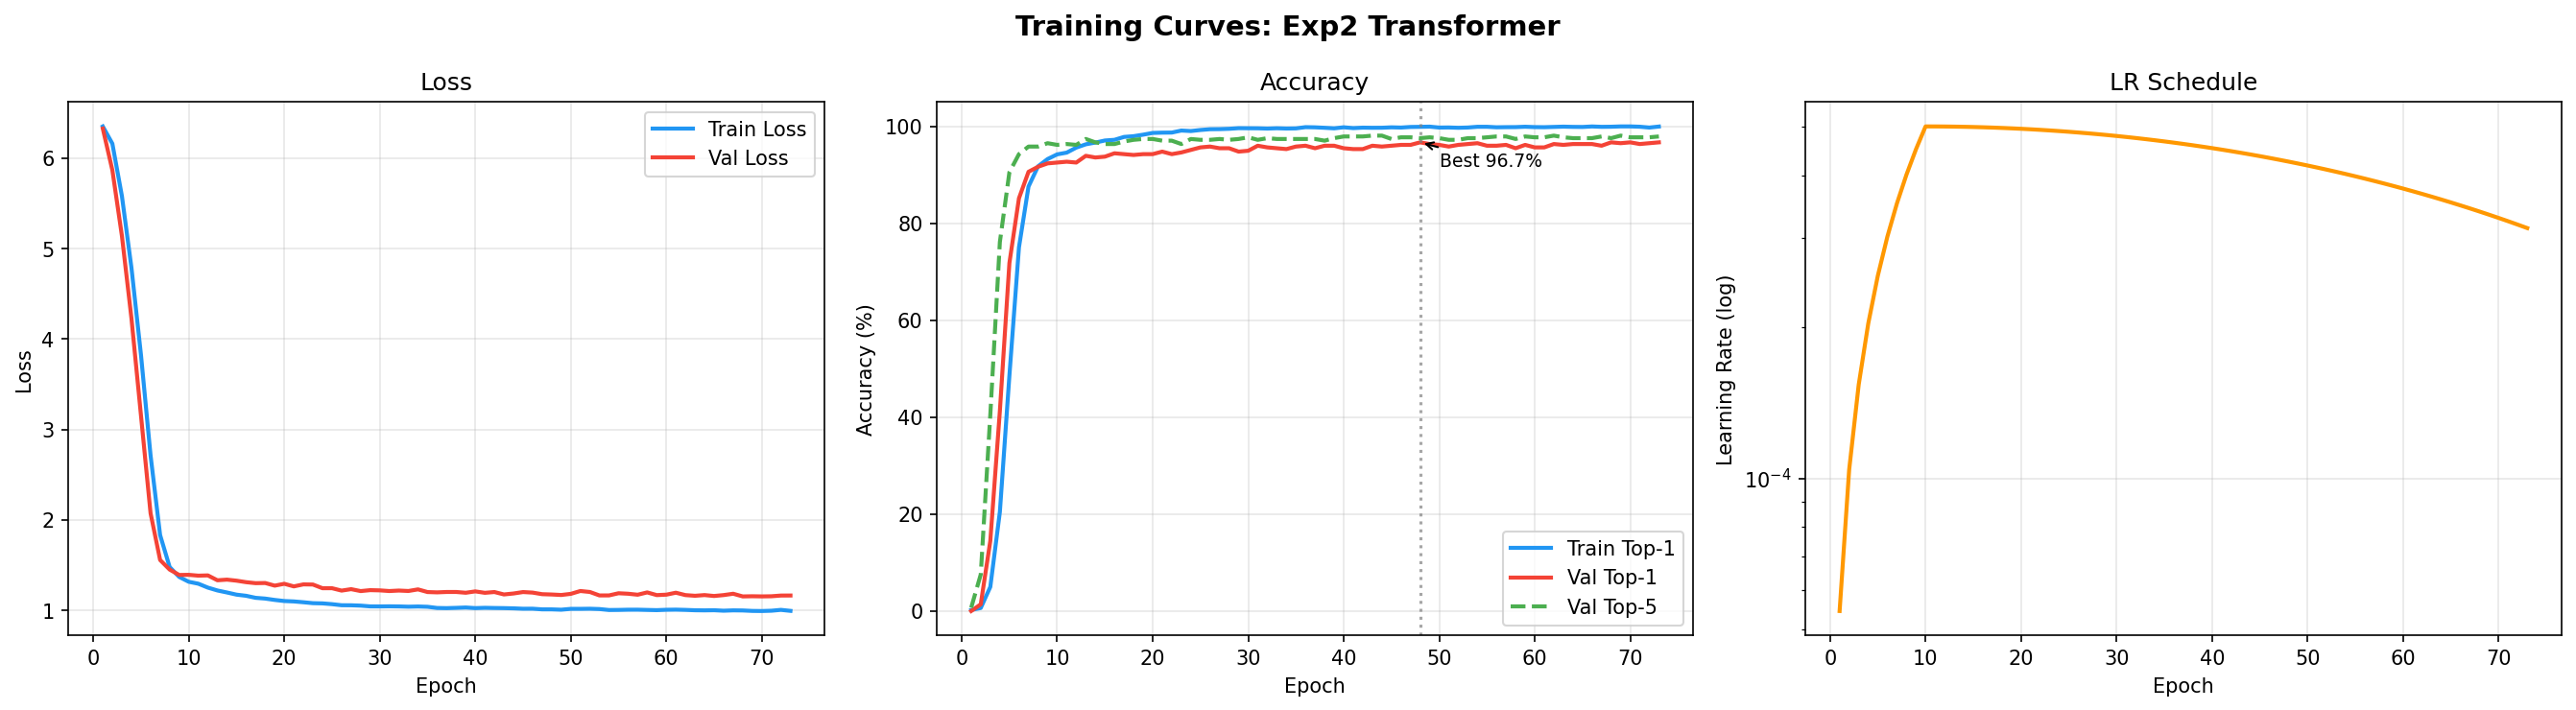

--- ST-GCN ---


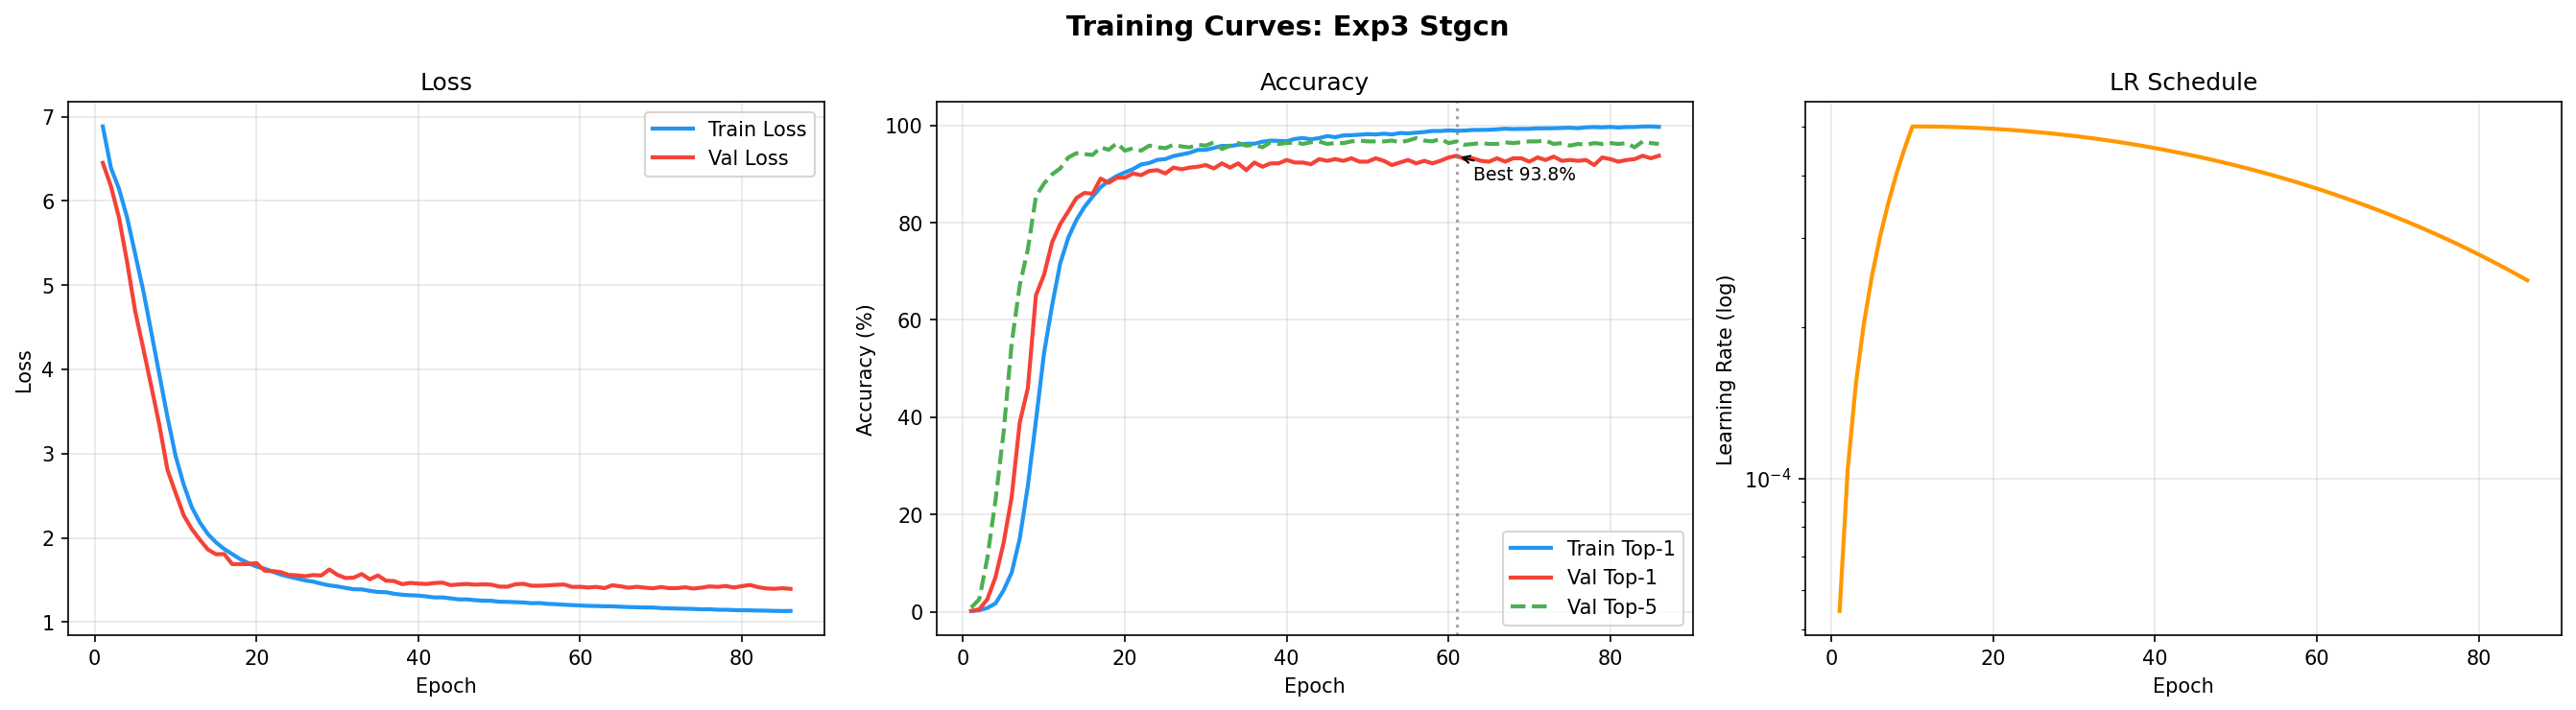

--- BiLSTM+Attention ---


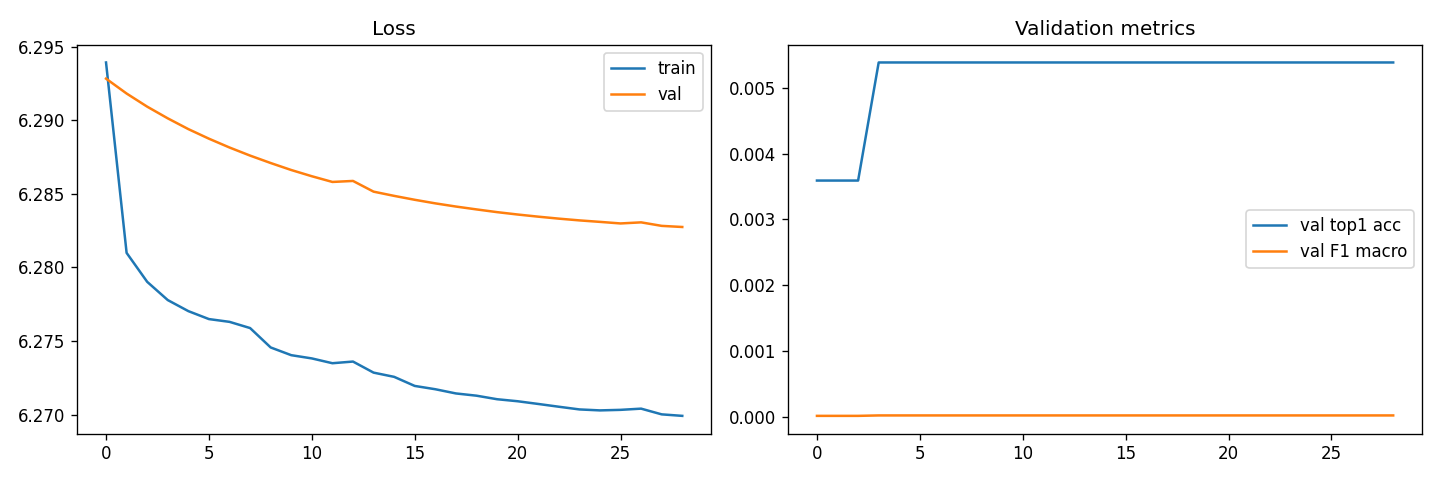

--- CNN1D+GRU ---


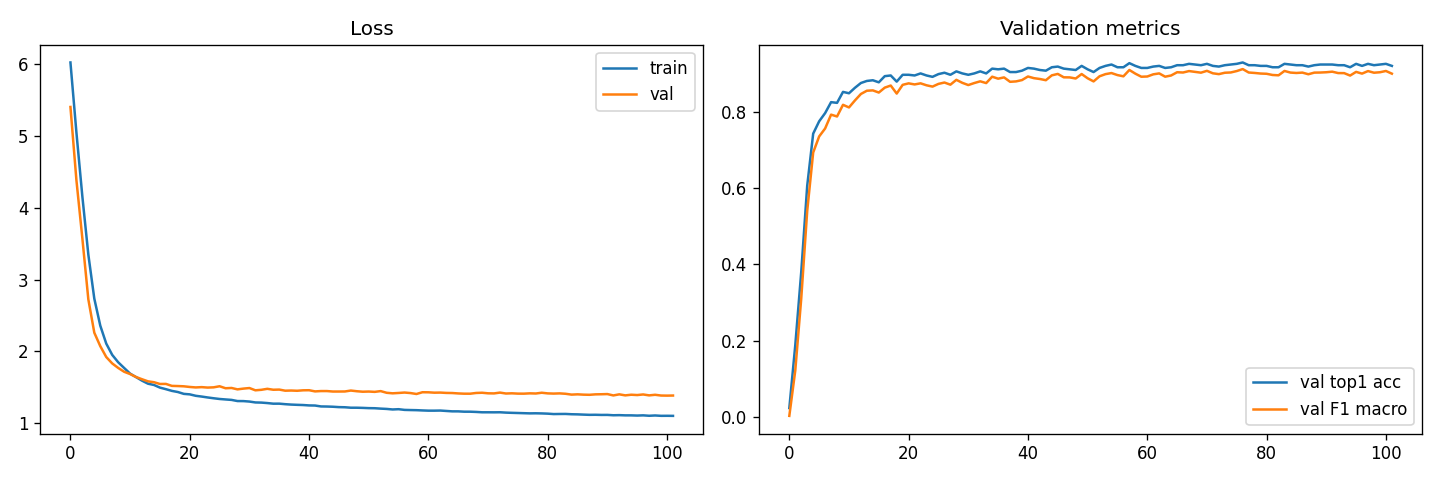

In [27]:
from IPython.display import Image, display

for name, exp in experiments:
    p = f'results/{exp}/training_curves.png'
    if os.path.exists(p):
        print(f'--- {name} ---')
        display(Image(filename=p))

## Step 11 — Confusion Matrices

--- Bi-LSTM ---


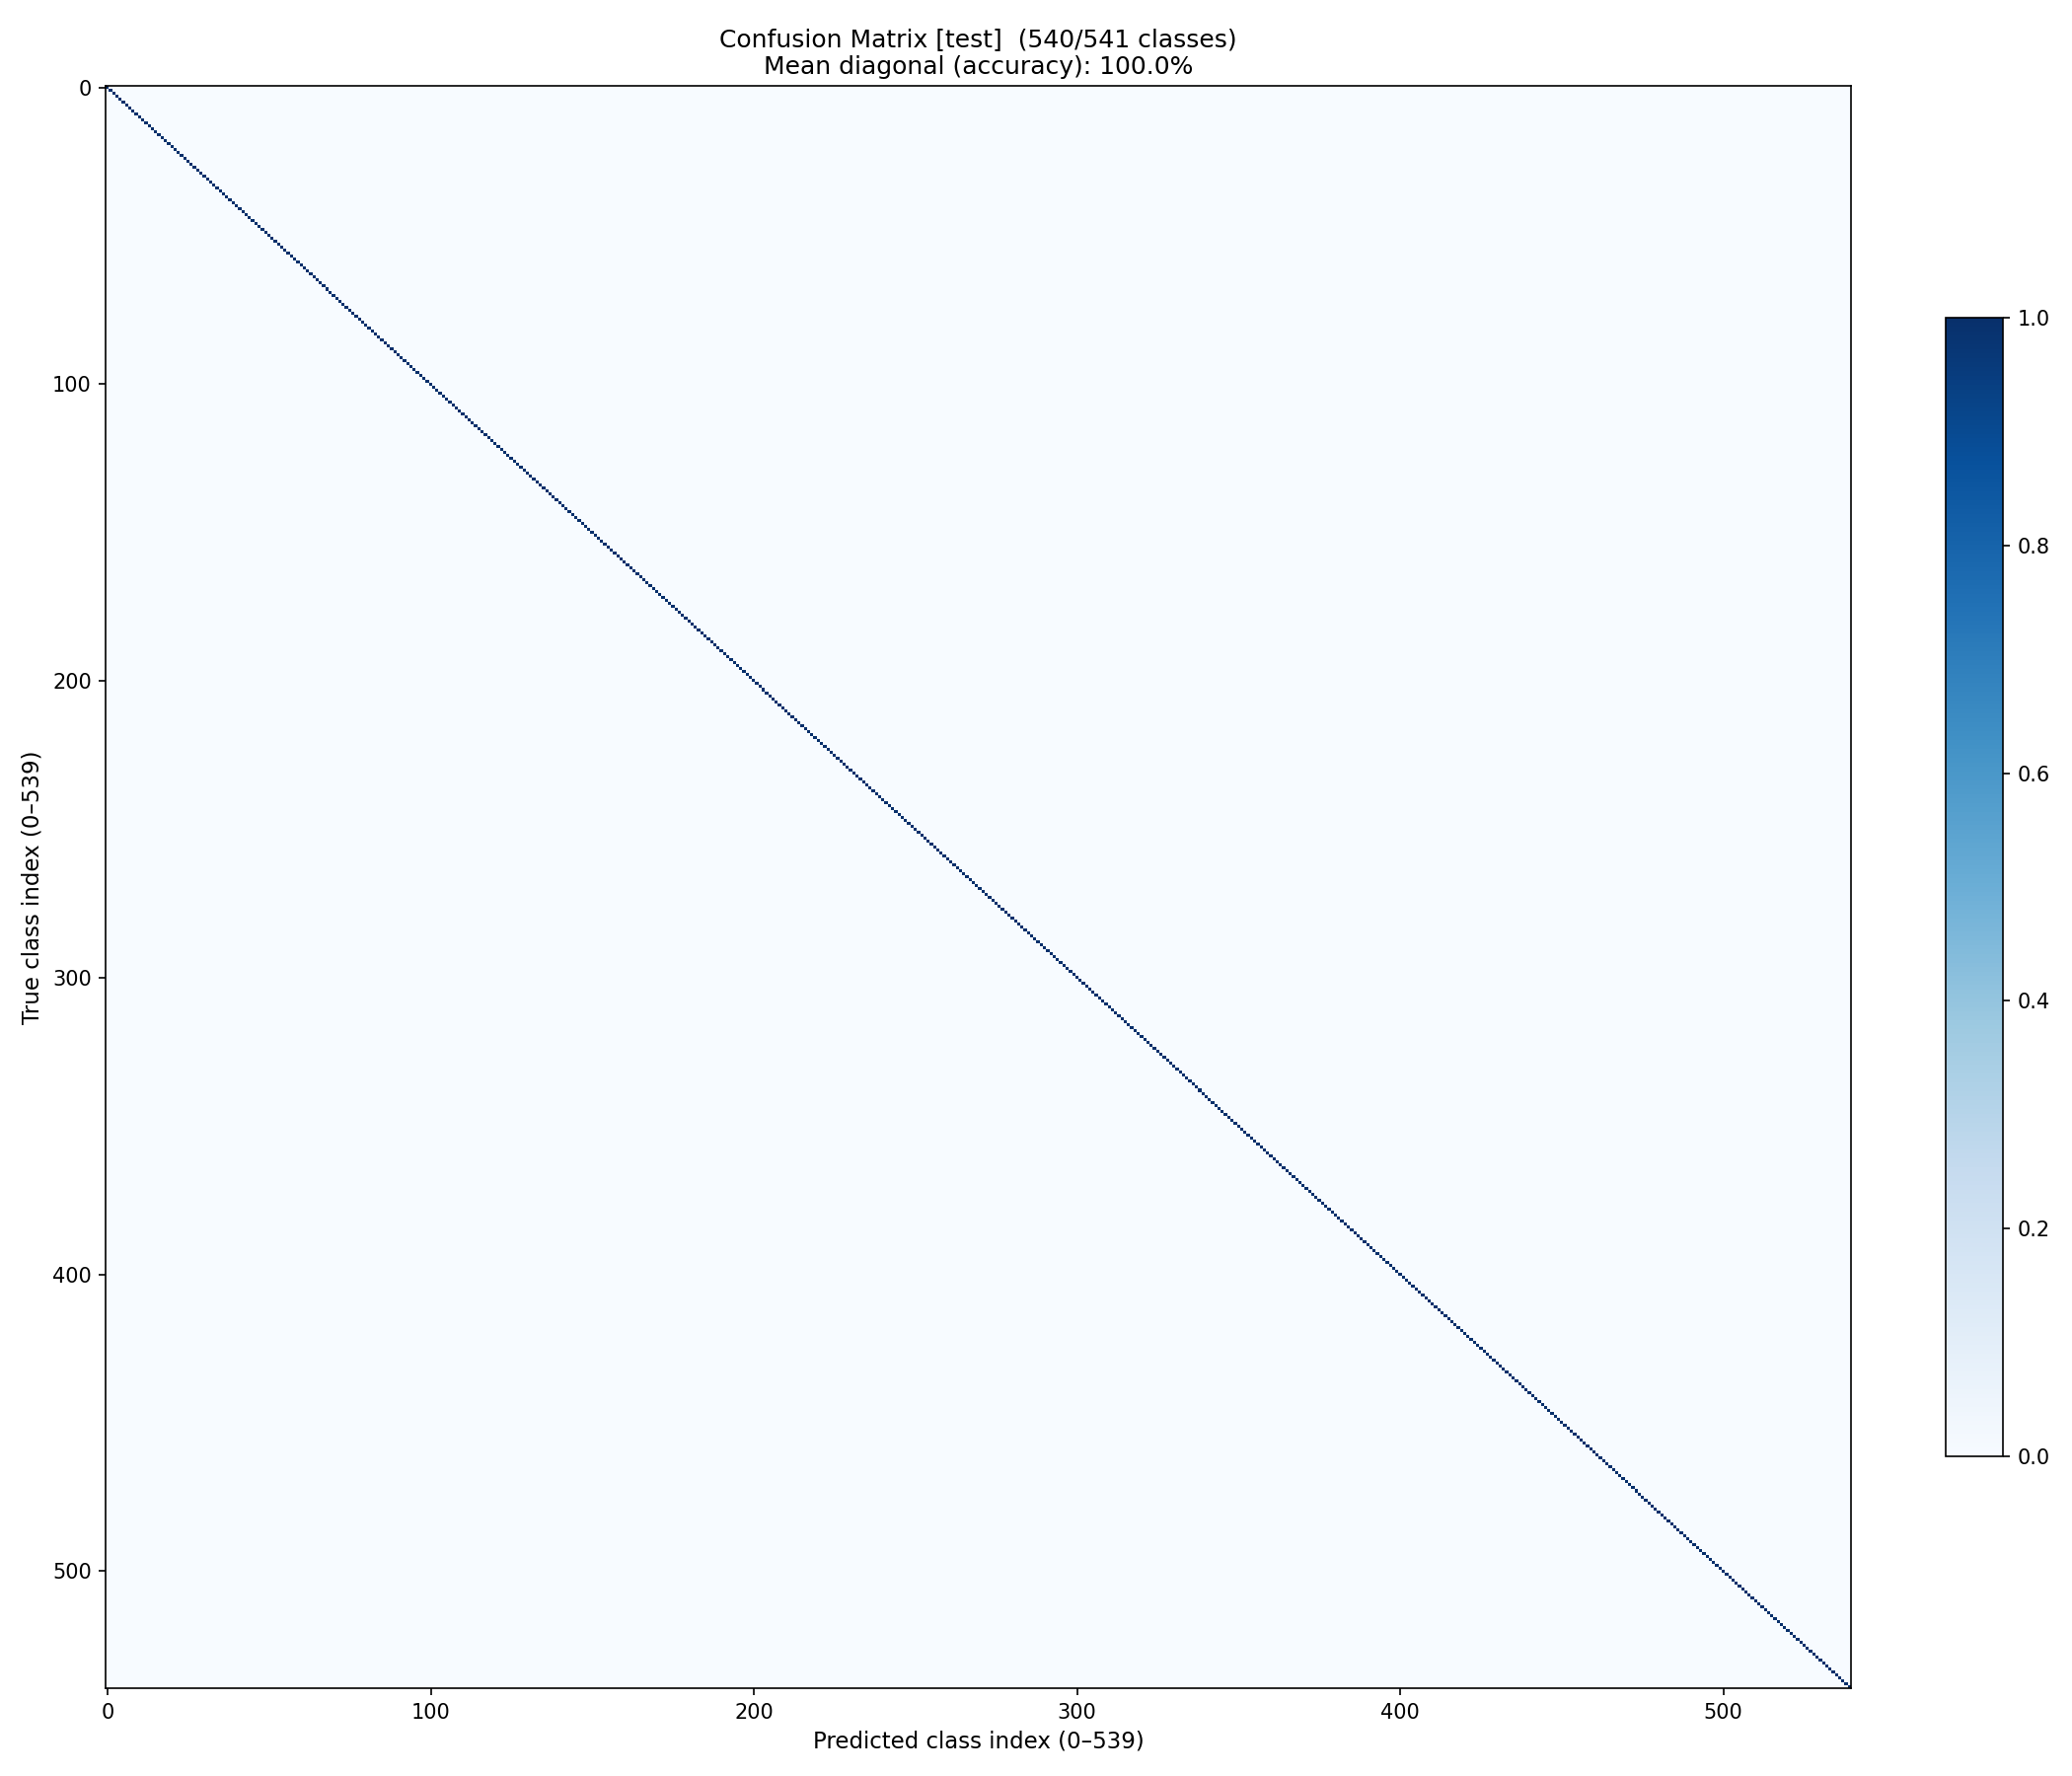

--- Transformer ---


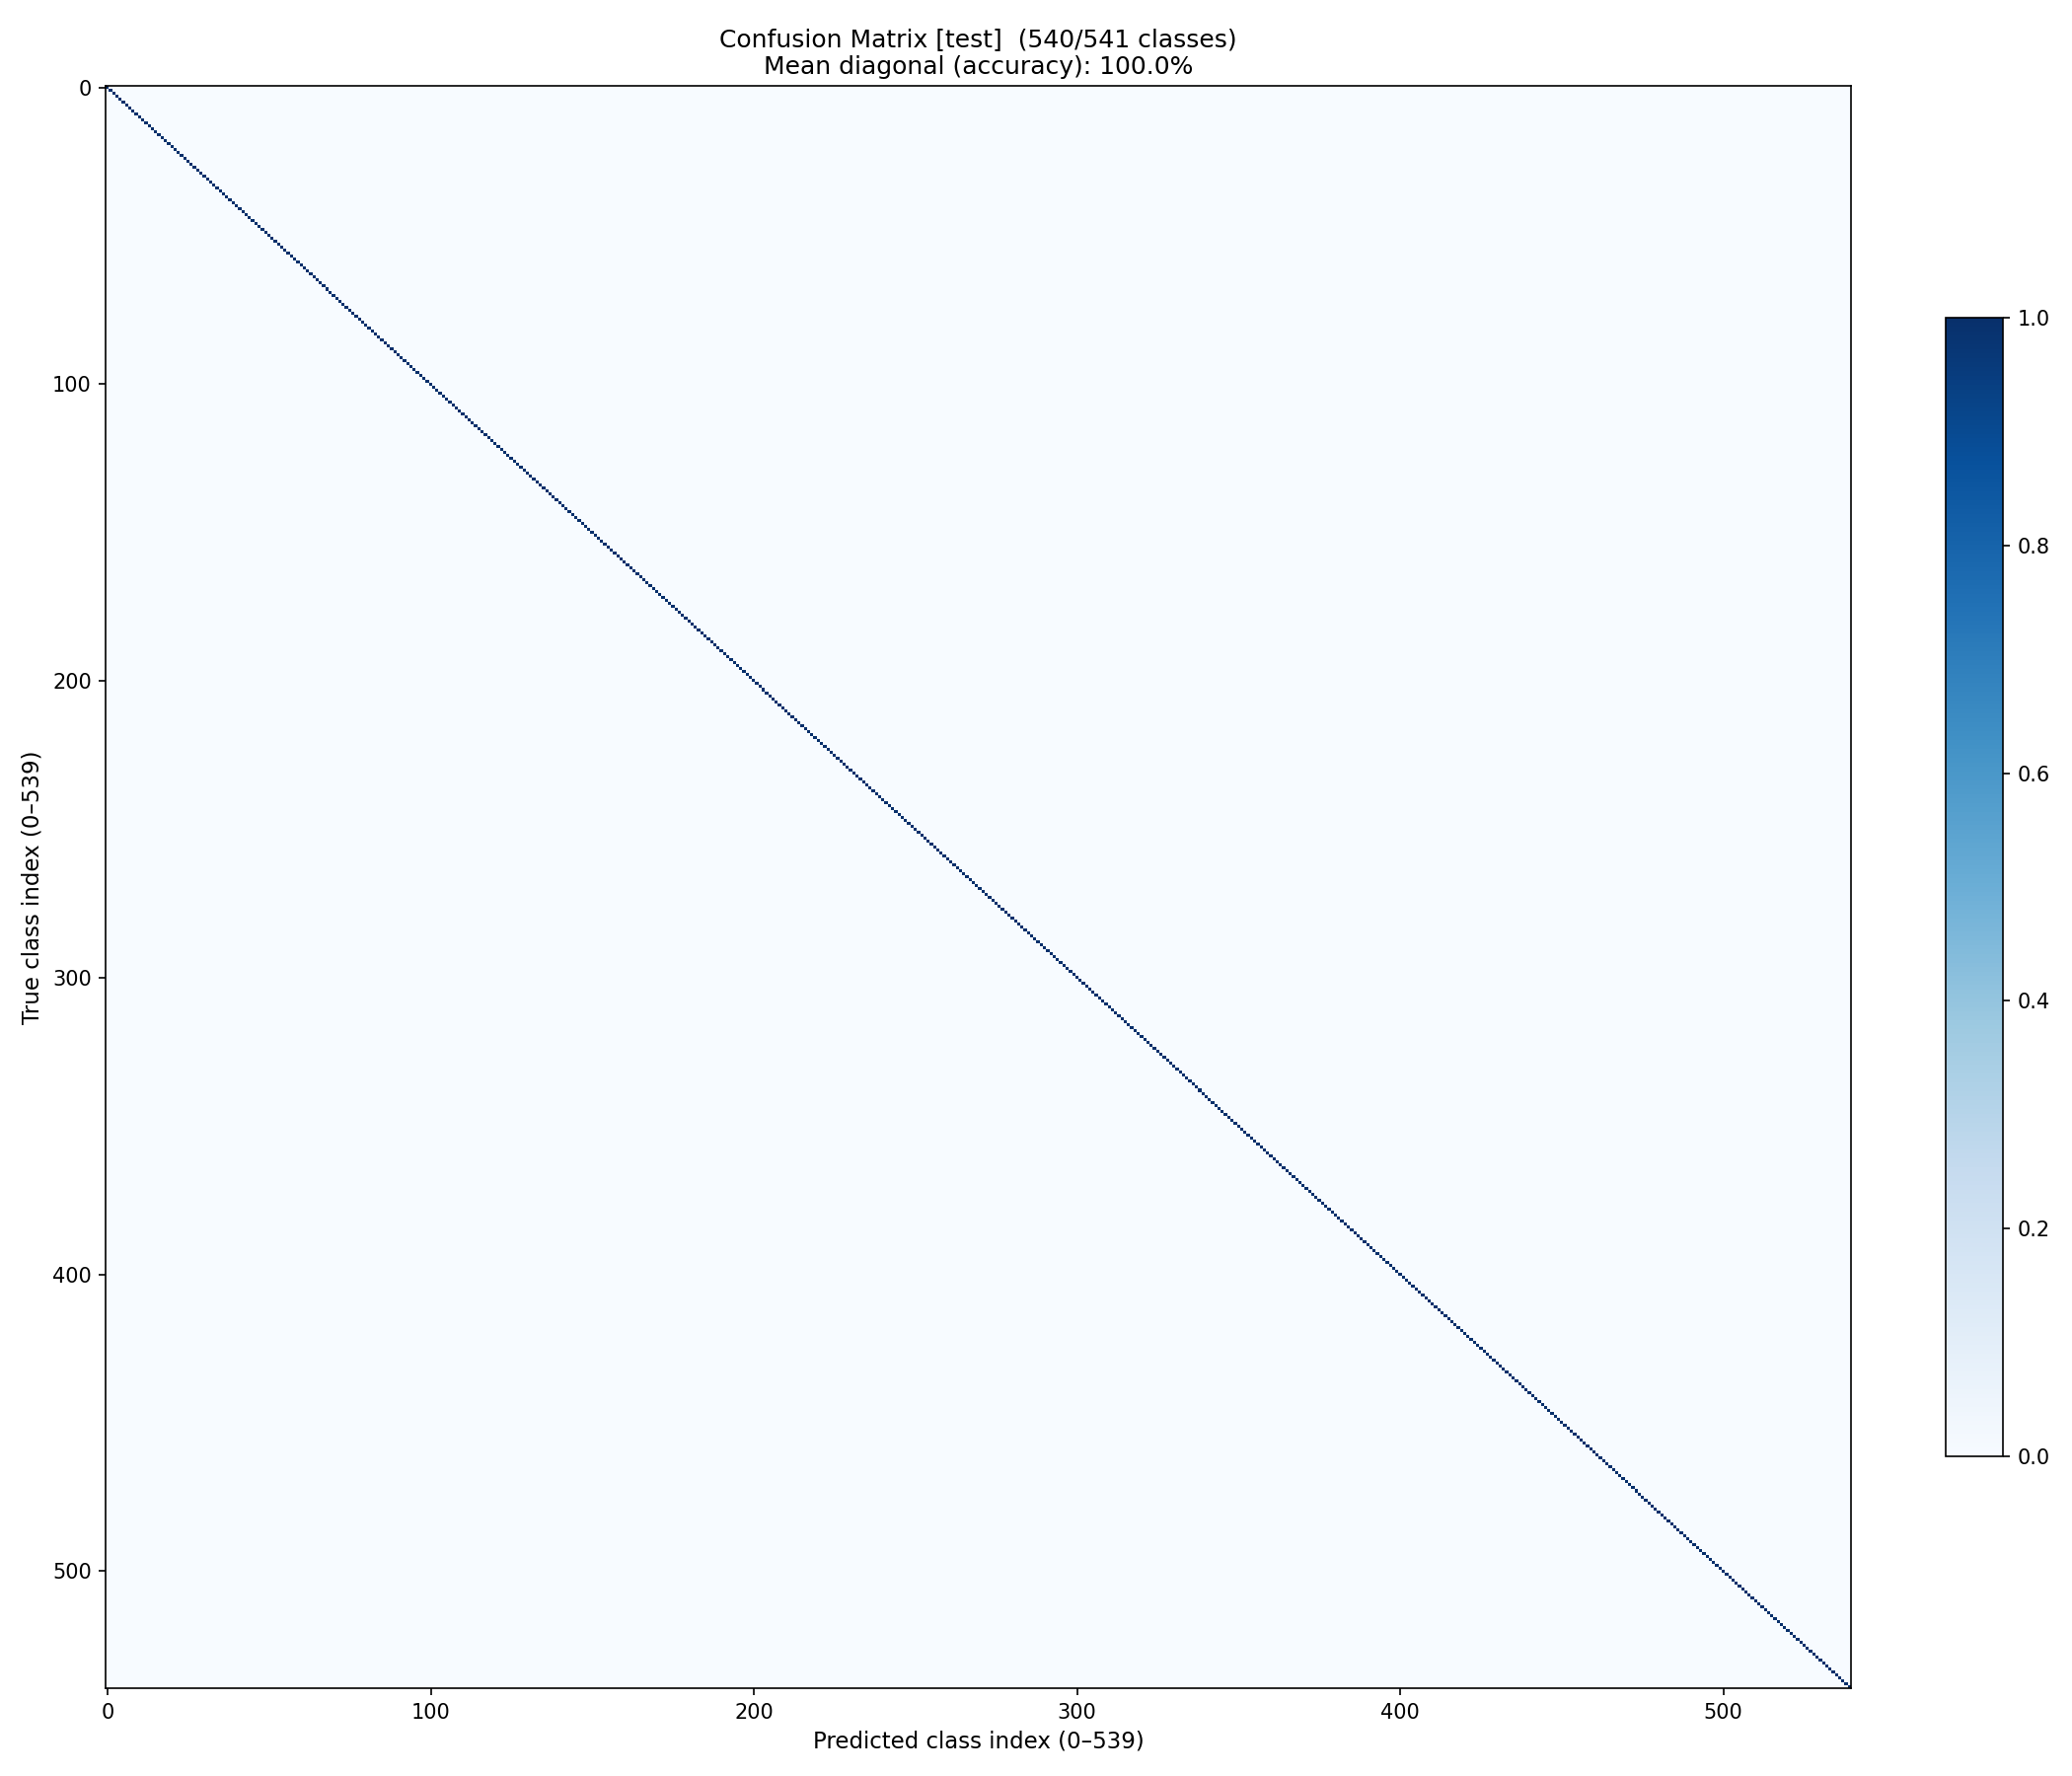

--- ST-GCN ---


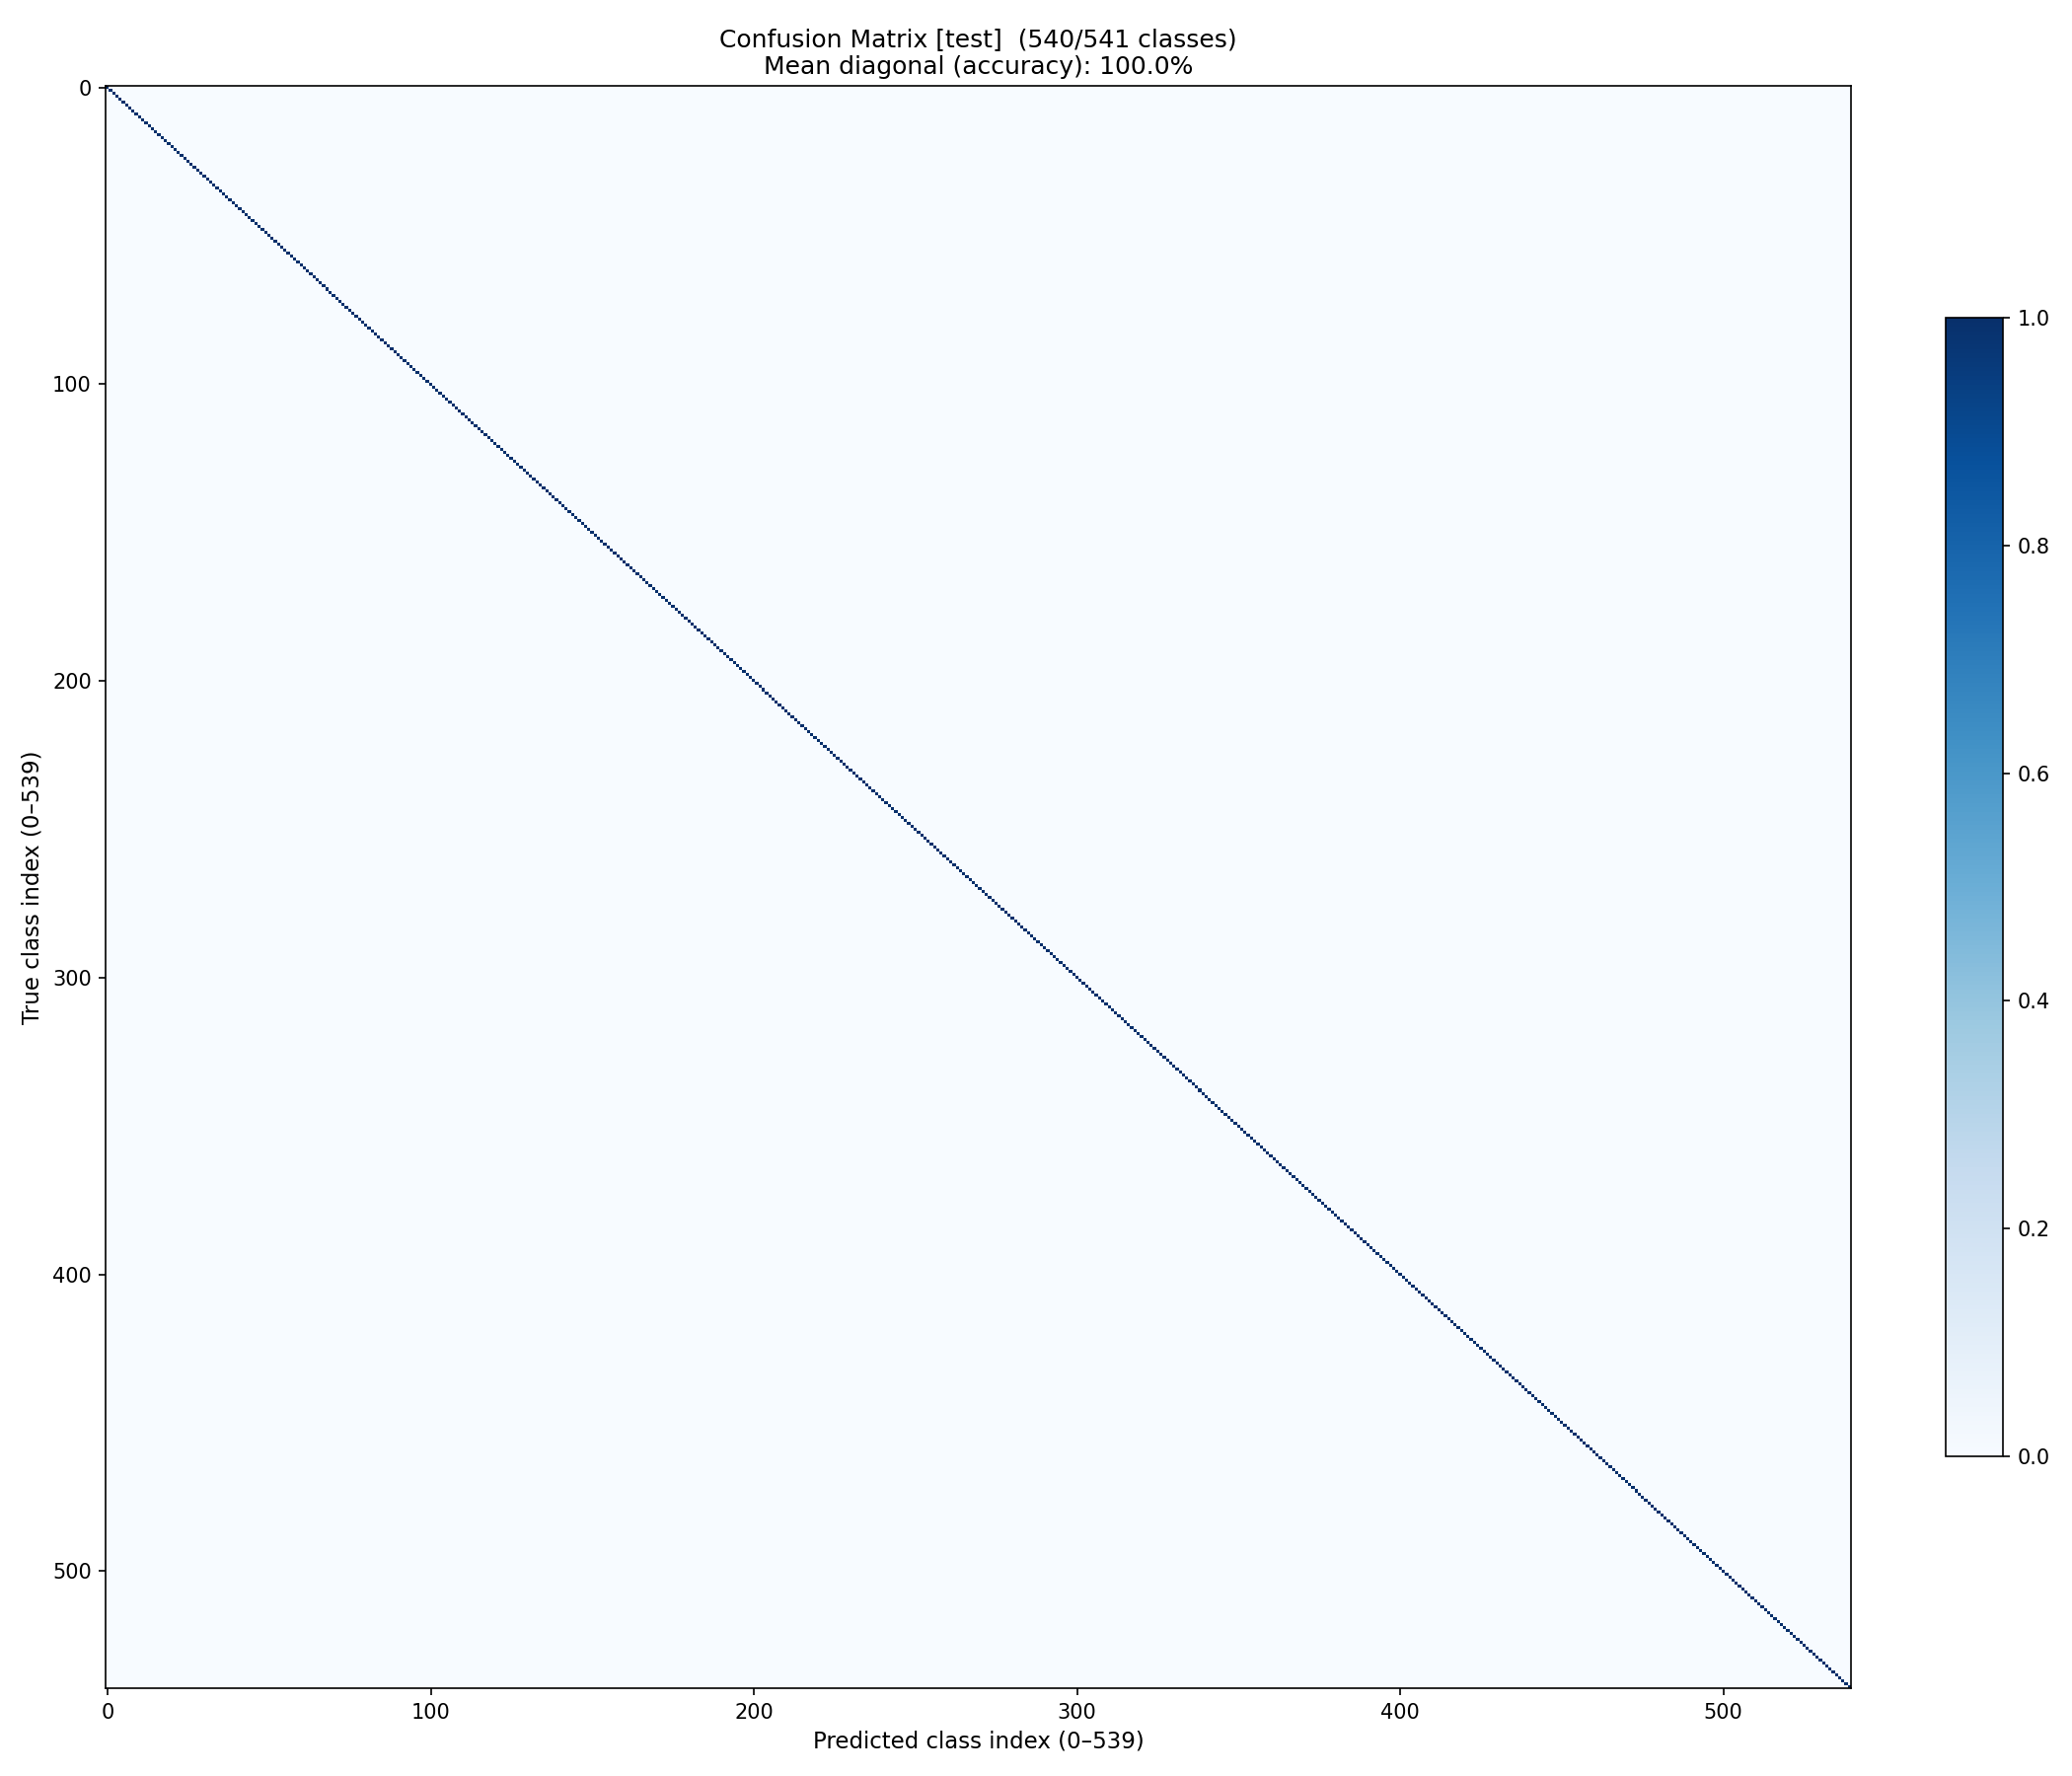

In [28]:
from IPython.display import Image, display

for name, exp in [('Bi-LSTM', 'exp1_bilstm'), ('Transformer', 'exp2_transformer'), ('ST-GCN', 'exp3_stgcn')]:
    p = f'results/{exp}/evaluation/confusion_matrix_test.png'
    if os.path.exists(p):
        print(f'--- {name} ---')
        display(Image(filename=p, width=900, height=650))

## Step 12 — Submission Checklist

In [29]:
files_to_check = [
    'config/config.yaml',
    f'{DATA_DIR}/label_map.json',
    f'{DATA_DIR}/augmented/augmented_manifest.json',
    f'{DATA_DIR}/multi_video_classes.json',
    'results/model_comparison.csv',
    'results/comparison_v6.png',
]
for name, exp in experiments:
    files_to_check.append(f'results/{exp}/training_curves.png')
    files_to_check.append(f'results/{exp}/evaluation/metrics_test.json')

for f in files_to_check:
    status = 'OK' if os.path.exists(f) else 'MISSING'
    print(f'  {status:8s} {f}')

  OK       config/config.yaml
  OK       /kaggle/working/data/label_map.json
  OK       /kaggle/working/data/augmented/augmented_manifest.json
  OK       /kaggle/working/data/multi_video_classes.json
  OK       results/model_comparison.csv
  OK       results/comparison_v6.png
  OK       results/exp1_bilstm/training_curves.png
  OK       results/exp1_bilstm/evaluation/metrics_test.json
  OK       results/exp2_transformer/training_curves.png
  OK       results/exp2_transformer/evaluation/metrics_test.json
  OK       results/exp3_stgcn/training_curves.png
  OK       results/exp3_stgcn/evaluation/metrics_test.json
  OK       results/exp4_bilstm_attn/training_curves.png
  OK       results/exp4_bilstm_attn/evaluation/metrics_test.json
  OK       results/exp5_cnn_gru/training_curves.png
  OK       results/exp5_cnn_gru/evaluation/metrics_test.json
